<a href="https://colab.research.google.com/github/KaueOPG/DCC127---Mineracao-de-Dados/blob/main/Trabalho2_Pre_processamento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 2 - Conhecendo e Pré-processando seus Dados

## Dayane Guimarães Gomes Godoy - 202265554C
## Kauê Oliveira Paraízo Garcia - 202265517B

## Anáslise Inicial

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import requests
from datetime import datetime
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

# 1. Montar o Google Drive

url = 'https://docs.google.com/spreadsheets/d/1F3ngeB1GYVwroXoMWzZZd0bhQUeJ6_mK6xicawUqTqM/export?format=csv'

df = pd.read_csv(url)

In [ ]:
display(df.head(10))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_3436344,Smoothie,2,4.0,8.0,NaN,NaN,28/02/2023
1,TXN_4630854,Tea,1,1.5,1.5,Digital Wallet,NaN,10/02/2023
2,TXN_4605871,Cookie,1,1.0,1.0,ERROR,ERROR,20/06/2023
3,TXN_2058243,Smoothie,5,4.0,20.0,NaN,Takeaway,19/03/2023
4,TXN_2050017,Sandwich,4,4.0,16.0,NaN,Takeaway,24/03/2023
5,TXN_5721215,Tea,2,1.5,3.0,NaN,Takeaway,17/05/2023
6,TXN_5927620,Smoothie,1,4.0,4.0,Credit Card,NaN,04/05/2023
7,TXN_3613385,Cookie,3,1.0,3.0,NaN,Takeaway,26/05/2023
8,TXN_1783857,Coffee,2,UNKNOWN,4.0,Digital Wallet,In-store,29/11/2023
9,TXN_5602640,Smoothie,5,4.0,20.0,NaN,Takeaway,01/04/2023


In [ ]:
# Entendendo o que tem em cada coluna
for col in df.columns:
    print(df[col].astype(str).str.upper().value_counts(), "\n")

Transaction ID
TXN_9882625    1
TXN_3436344    1
TXN_4630854    1
TXN_4605871    1
TXN_2058243    1
              ..
TXN_3223187    1
TXN_6708156    1
TXN_2809397    1
TXN_5602640    1
TXN_1783857    1
Name: count, Length: 7000, dtype: int64 

Item
JUICE       838
SANDWICH    805
COFFEE      799
SALAD       797
CAKE        783
COOKIE      782
SMOOTHIE    771
TEA         760
UNKNOWN     239
NAN         215
ERROR       211
Name: count, dtype: int64 

Quantity
5          1432
2          1351
3          1311
4          1306
1          1281
ERROR       129
UNKNOWN      98
NAN          92
Name: count, dtype: int64 

Price Per Unit
3.0        1710
4.0        1632
5.0         839
2.0         836
1.0         803
1.5         795
ERROR       133
NAN         131
UNKNOWN     121
Name: count, dtype: int64 

Total Spent
6.0        684
12.0       660
4.0        649
3.0        643
15.0       528
20.0       519
8.0        452
10.0       372
9.0        343
5.0        342
2.0        340
16.0       316
25.

In [ ]:
print(f"Total de linhas: {df.shape[0]} | Total de colunas: {df.shape[1]}")

Total de linhas: 7000 | Total de colunas: 8


In [ ]:
# Substituindo valores invalidos por Nan
valores_invalidos = ["ERROR", "UNKNOWN", "NAN"]
df = df.replace(valores_invalidos, np.nan)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    7000 non-null   object
 1   Item              6335 non-null   object
 2   Quantity          6681 non-null   object
 3   Price Per Unit    6615 non-null   object
 4   Total Spent       6653 non-null   object
 5   Payment Method    4823 non-null   object
 6   Location          4229 non-null   object
 7   Transaction Date  6680 non-null   object
dtypes: object(8)
memory usage: 437.6+ KB
None


Text(0.5, 1.0, 'Verificação de unicidade do Transaction ID')

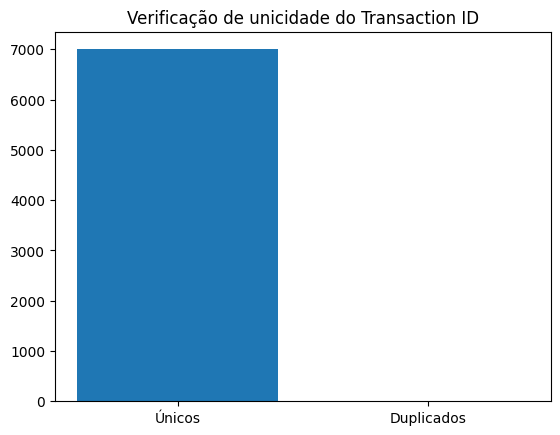

In [ ]:
unique = df['Transaction ID'].nunique()
total = len(df)

plt.bar(['Únicos', 'Duplicados'], [unique, total - unique])
plt.title('Verificação de unicidade do Transaction ID')

A coluna "Transaction ID" possuem ids válidos e únicos, então não será preciso mexer nela. Optei por deixa-la para se caso houver uma base de clientes linkada por Transaction ID conseguimos recuperar depois


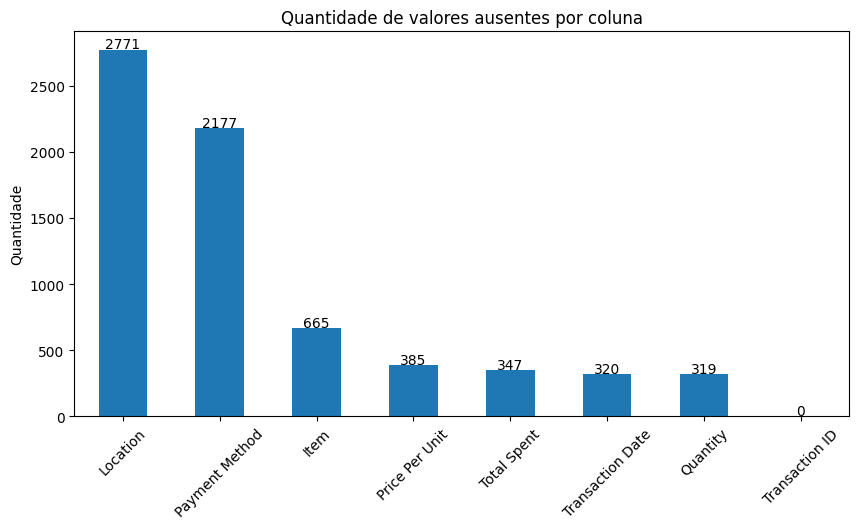

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

contagem_invalidos = df.isna().sum().sort_values(ascending=False)

ax = contagem_invalidos.plot(kind='bar', figsize=(10,5))
plt.title("Quantidade de valores ausentes por coluna")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)

for i, v in enumerate(contagem_invalidos):
    ax.text(i, v + 10, str(v), ha='center')

plt.show()

In [ ]:
display(df.head(10))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_3436344,Smoothie,2,4.0,8.0,NaN,NaN,28/02/2023
1,TXN_4630854,Tea,1,1.5,1.5,Digital Wallet,NaN,10/02/2023
2,TXN_4605871,Cookie,1,1.0,1.0,NaN,NaN,20/06/2023
3,TXN_2058243,Smoothie,5,4.0,20.0,NaN,Takeaway,19/03/2023
4,TXN_2050017,Sandwich,4,4.0,16.0,NaN,Takeaway,24/03/2023
5,TXN_5721215,Tea,2,1.5,3.0,NaN,Takeaway,17/05/2023
6,TXN_5927620,Smoothie,1,4.0,4.0,Credit Card,NaN,04/05/2023
7,TXN_3613385,Cookie,3,1.0,3.0,NaN,Takeaway,26/05/2023
8,TXN_1783857,Coffee,2,NaN,4.0,Digital Wallet,In-store,29/11/2023
9,TXN_5602640,Smoothie,5,4.0,20.0,NaN,Takeaway,01/04/2023


In [ ]:
total_duplicadas = df.duplicated().sum()

df = df.drop_duplicates(keep='first')

df = df.reset_index(drop=True)

print(f"Foram removidas {total_duplicadas} linhas duplicadas.")

Foram removidas 0 linhas duplicadas.


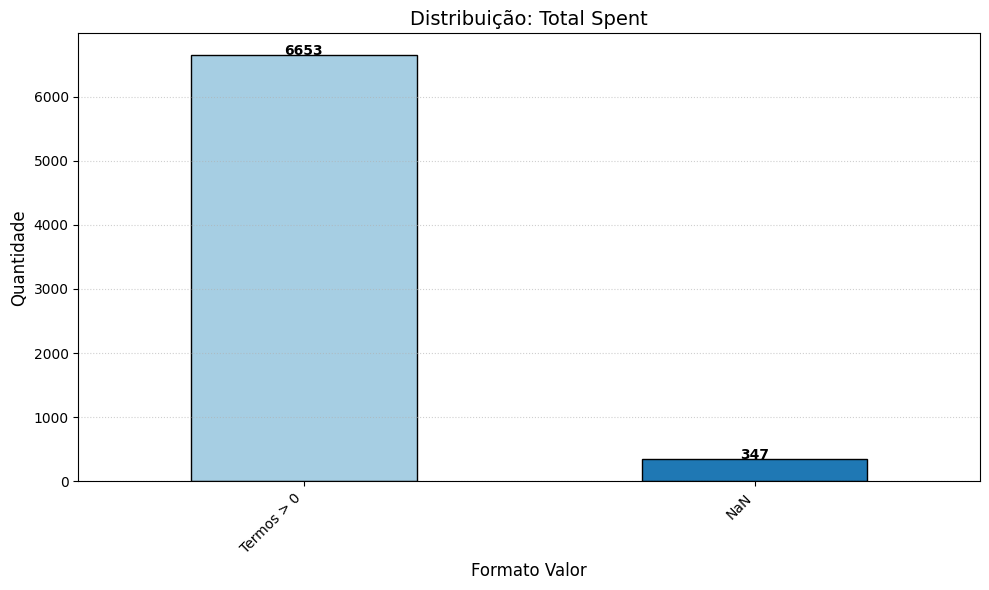

In [ ]:
def categorizar_bruto(valor):
    if pd.isna(valor):
        return 'NaN'
    try:
        num = float(valor)
        if num > 0:
            return 'Termos > 0'
        else:
            return 'Termos <= 0'
    except (ValueError, TypeError):

        return str(valor)

df['Categoria_Temp'] = df['Total Spent'].apply(categorizar_bruto)

contagem = df['Categoria_Temp'].value_counts()

plt.figure(figsize=(10, 6))
cores = plt.cm.Paired(range(len(contagem)))

contagem.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Distribuição: Total Spent', fontsize=14)
plt.xlabel('Formato Valor', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)

for i, v in enumerate(contagem):
    plt.text(i, v, str(v), ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

df.drop(columns=['Categoria_Temp'], inplace=True)

### Payment Method

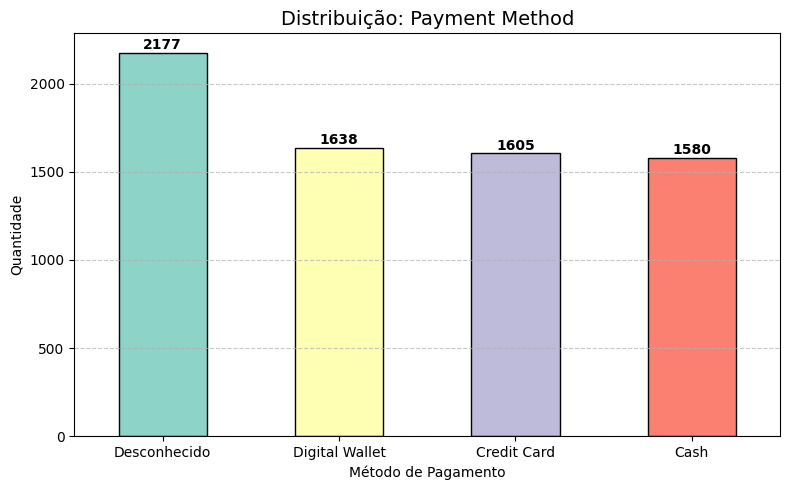

In [ ]:
invalidos = ['NAN', 'ERROR', 'UNKNOWN']

def limpar_pagamento(valor):
    if pd.isna(valor):
        return 'Desconhecido'

    valor_str = str(valor).strip().upper()

    if valor_str in invalidos or valor_str == '':
        return 'Desconhecido'

    return str(valor).strip().title()

df['Payment Method'] = df['Payment Method'].apply(limpar_pagamento)

contagem_pagamento = df['Payment Method'].value_counts()

plt.figure(figsize=(8, 5))
cores = plt.cm.Set3(range(len(contagem_pagamento)))

contagem_pagamento.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Distribuição: Payment Method', fontsize=14)
plt.ylabel('Quantidade')
plt.xlabel('Método de Pagamento')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(contagem_pagamento):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Location

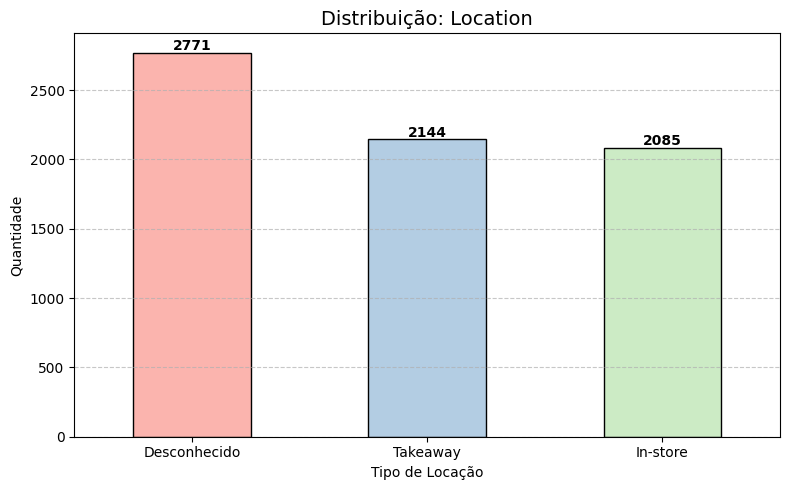

In [ ]:
erros_conhecidos = ['NaN', 'ERROR', 'UNKNOWN']

def limpar_location(valor):
    if pd.isna(valor):
        return 'Desconhecido'

    valor_str = str(valor).strip().upper()

    if valor_str in erros_conhecidos or valor_str == '':
        return 'Desconhecido'
    return str(valor).strip().capitalize()

df['Location'] = df['Location'].apply(limpar_location)

contagem_location = df['Location'].value_counts()

plt.figure(figsize=(8, 5))
cores = plt.cm.Pastel1(range(len(contagem_location)))

contagem_location.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Distribuição: Location', fontsize=14)
plt.ylabel('Quantidade')
plt.xlabel('Tipo de Locação')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(contagem_location):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Transaction Date

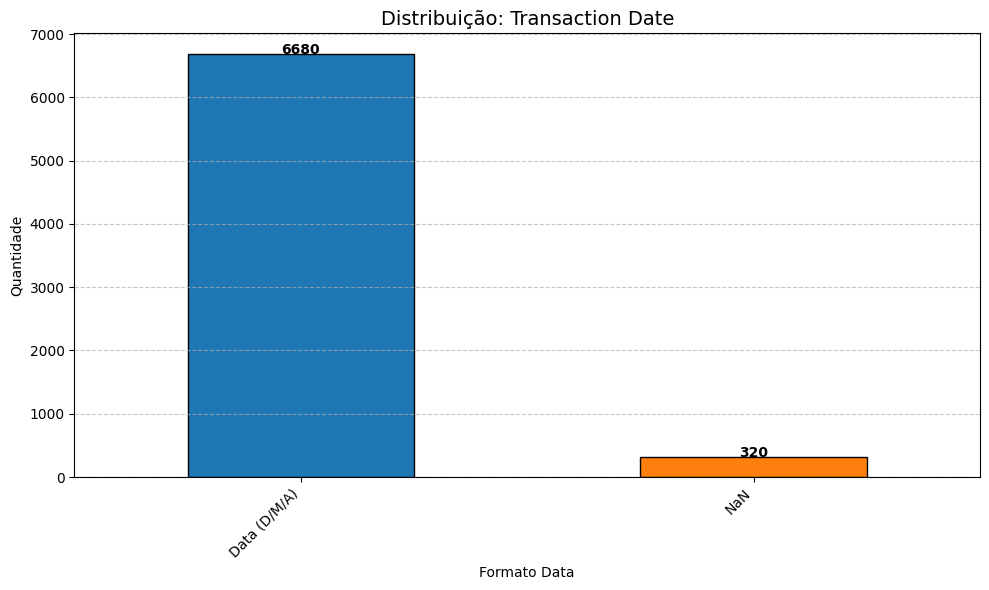

In [ ]:
def categorizar_data(valor):
    if pd.isna(valor):
        return 'NaN'
    valor_str = str(valor).strip()

    try:
        data_obj = datetime.strptime(valor_str, '%d/%m/%Y')
        return 'Data (D/M/A)'

    except ValueError:
        if '/' in valor_str and valor_str.count('/') == 2:
            return 'Data Inválida'
        else:
            return valor_str

df['Formato Data'] = df['Transaction Date'].apply(categorizar_data)

contagem_data = df['Formato Data'].value_counts()

plt.figure(figsize=(10, 6))
cores = plt.cm.tab10(range(len(contagem_data)))

contagem_data.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Distribuição: Transaction Date', fontsize=14)
plt.ylabel('Quantidade')
plt.xlabel('Formato Data')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(contagem_data):
    plt.text(i, v, str(v), ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

df.drop(columns=['Formato Data'], inplace=True)

df = df.dropna(subset=['Transaction Date']).copy()

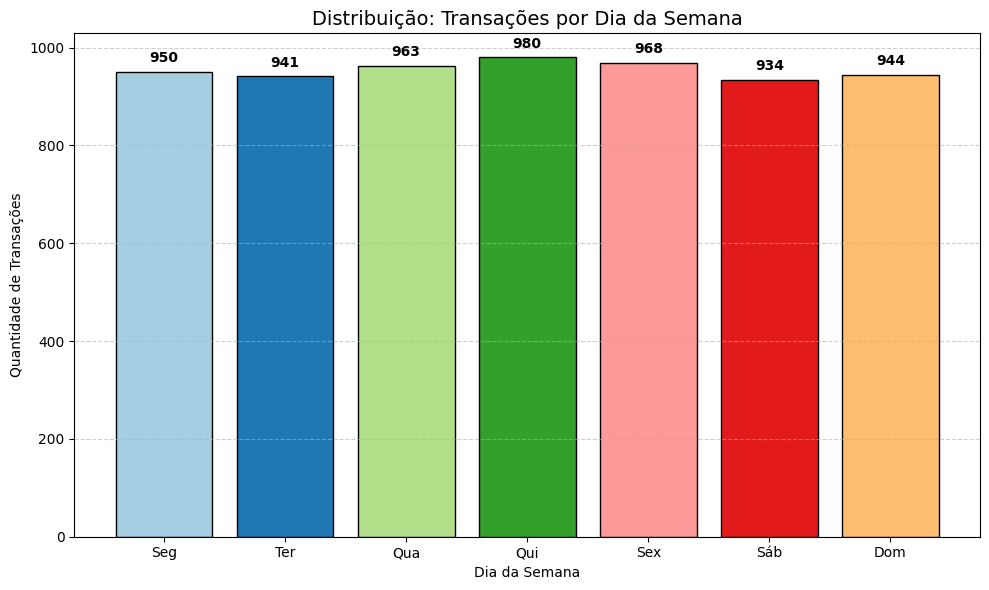

In [ ]:
datas_convertidas = pd.to_datetime(df['Transaction Date'], format='%d/%m/%Y', errors='coerce')

df['Week Day'] = datas_convertidas.dt.dayofweek + 1

df['Week Day'] = df['Week Day'].fillna(0).astype(int)

contagem_dias = df['Week Day'].value_counts().sort_index()

labels = {
    1: 'Seg', 2: 'Ter', 3: 'Qua',
    4: 'Qui', 5: 'Sex', 6: 'Sáb', 7: 'Dom'
}
nomes_dias = [labels[i] for i in contagem_dias.index]

plt.figure(figsize=(10, 6))
cores_dias = plt.cm.Paired(range(len(contagem_dias)))

plt.bar(nomes_dias, contagem_dias.values, color=cores_dias, edgecolor='black')

for i, v in enumerate(contagem_dias.values):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.title('Distribuição: Transações por Dia da Semana', fontsize=14)
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Transações')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



## Tratamento

#### Recuperando dados inválidos da coluna de "Item", "Price Per Unit" e "Quantity"

In [ ]:
len(df)

6680

In [ ]:
result = df.groupby("Item", dropna=False)["Price Per Unit"]\
    .apply(lambda x: list(pd.Series(x).unique()))

for item, prices in result.items():
    print(f"{item} -> {prices}")

Cake -> ['3.0', nan]
Coffee -> [nan, '2.0']
Cookie -> ['1.0', nan]
Juice -> ['3.0', nan]
Salad -> ['5.0', nan]
Sandwich -> ['4.0', nan]
Smoothie -> ['4.0', nan]
Tea -> ['1.5', nan]
nan -> ['3.0', '5.0', nan, '4.0', '1.5', '1.0', '2.0']


Agrupei os dados pela coluna "Item" e, para cada produto, listei os valores únicos encontrados na coluna "Price Per Unit". Isso permite visualizar todos os preços associados a cada item, incluindo valores inconsistentes. É possível observar que cada produto possui apenas um preço válido, indicando que não há variação real de preço, mas sim problemas de qualidade nos dados. Portanto, o próximo passo é substituir esses valores incorretos

1.   Cake -> 3.0
2.   Coffee -> 2.0
3.   Cookie -> 1.0
4.   Juice -> 3.0
5.   Salad -> 5.0
6.   Sandwich -> 4.0
7.   Smoothie -> 4.0
8.   Tea -> 1.5

Nessa etapa não tratei valores como cake e juice, e sandwich e smoothie pois possuem o mesmo preço, então não conseguimos inferir qual é o item apenas com o preço





<Axes: xlabel='Item'>

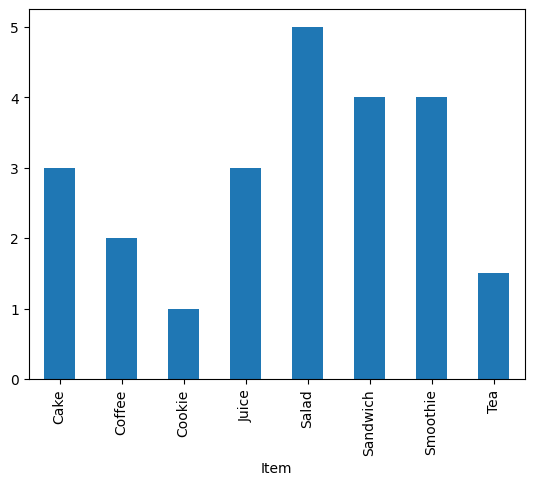

In [ ]:
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df.groupby("Item")["Price Per Unit"].mean().plot(kind="bar")

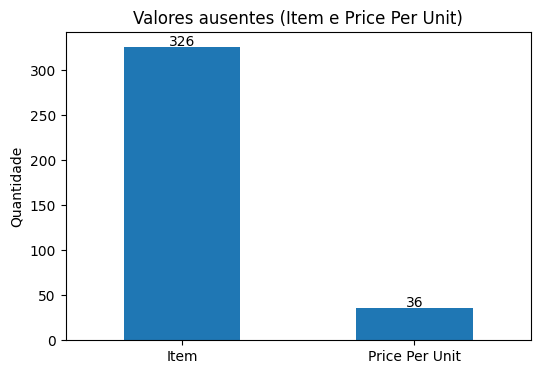



Cake -> [np.float64(3.0)]
Coffee -> [np.float64(2.0)]
Cookie -> [np.float64(1.0)]
Juice -> [np.float64(3.0)]
Salad -> [np.float64(5.0)]
Sandwich -> [np.float64(4.0)]
Smoothie -> [np.float64(4.0)]
Tea -> [np.float64(1.5)]
nan -> [np.float64(3.0), np.float64(nan), np.float64(4.0)]


In [ ]:
# Corrigindo os preços dos itens
price_map = {
    "Cake": 3.0,
    "Coffee": 2.0,
    "Cookie": 1.0,
    "Juice": 3.0,
    "Salad": 5.0,
    "Sandwich": 4.0,
    "Smoothie": 4.0,
    "Tea": 1.5
}

df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")

df["Price Per Unit"] = df.apply(
    lambda row: price_map[row["Item"]]
    if row["Item"] in price_map and pd.isna(row["Price Per Unit"])
    else row["Price Per Unit"],
    axis=1
)

# Corrigindo os itens incosistentes
price_counts = df.groupby("Price Per Unit")["Item"].nunique()

precos_unicos = price_counts[price_counts == 1].index

item_map = {
    v: k for k, v in price_map.items()
    if v in precos_unicos
}

df["Item"] = df.apply(
    lambda row: item_map.get(float(row["Price Per Unit"]), row["Item"])
    if pd.isna(row["Item"])
    else row["Item"],
    axis=1
)

cols = ["Item", "Price Per Unit"]

contagem_invalidos = df[cols].isna().sum()

ax = contagem_invalidos.plot(kind='bar', figsize=(6,4))
plt.title("Valores ausentes (Item e Price Per Unit)")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

for i, v in enumerate(contagem_invalidos):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

result = df.groupby("Item", dropna=False)["Price Per Unit"]\
    .apply(lambda x: list(pd.Series(x).unique()))

print("\n")
for item, prices in result.items():
    print(f"{item} -> {prices}")

Com esse ultimo output, percebemos que alguns registros não têm preço
e também não têm item válido, mas ainda dá para recuperar esses dados caso eles tenham preço total e quantidade:
$$
\text{Preço Unitário} = \frac{\text{Preço Total}}{\text{Quantidade}}
$$

E a partir desse preço unitário dá para inferir qual item é

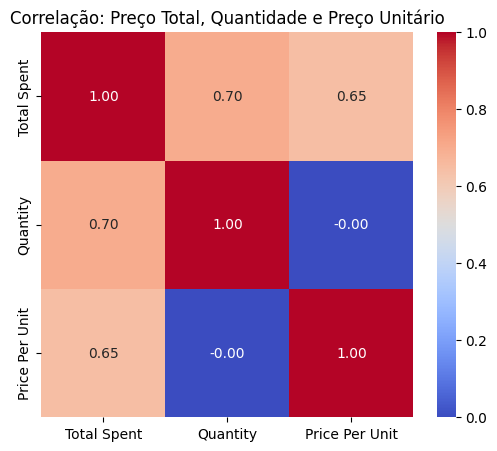

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Total Spent', 'Quantity', 'Price Per Unit']

corr = df[cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlação: Preço Total, Quantidade e Preço Unitário")
plt.show()

In [ ]:
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce") # Transforma números em float/int e erros em Nan
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Total Spent"] / df["Quantity"]
)

print(df[df["Item"].isna()])
print("\nQuantidade de itens não identificados: ",len(df[df["Item"].isna()]))

     Transaction ID Item  Quantity  Price Per Unit  Total Spent  \
19      TXN_6855453  NaN       4.0             3.0         12.0   
32      TXN_9702662  NaN       4.0             4.0         16.0   
34      TXN_6616787  NaN       2.0             3.0          6.0   
39      TXN_2644561  NaN       4.0             4.0         16.0   
56      TXN_2402637  NaN       2.0             4.0          8.0   
...             ...  ...       ...             ...          ...   
6938    TXN_7595907  NaN       5.0             3.0         15.0   
6942    TXN_1349215  NaN       NaN             4.0          4.0   
6945    TXN_1917388  NaN       2.0             3.0          6.0   
6969    TXN_8297135  NaN       2.0             4.0          NaN   
6992    TXN_5031214  NaN       5.0             1.0          5.0   

      Payment Method      Location Transaction Date  Week Day  
19      Desconhecido      In-store       17/07/2023         1  
32      Desconhecido      Takeaway       10/07/2023         1  
34 

In [ ]:
# Recuperar itens novamente depois do cálculo do preço unitário a partir do total gasto e da quantidade
price_counts = df.groupby("Price Per Unit")["Item"].nunique()

precos_unicos = price_counts[price_counts == 1].index

item_map = {
    v: k for k, v in price_map.items()
    if v in precos_unicos
}

df["Item"] = df.apply(
    lambda row: item_map.get(row["Price Per Unit"], row["Item"])
    if ( pd.isna(row["Item"]))
       and not pd.isna(row["Price Per Unit"])
    else row["Item"],
    axis=1
)

# Restaurando a coluna "Quantity"
df["Quantity"] = df["Quantity"].fillna(
    df.apply(
        lambda row: row["Total Spent"] / row["Price Per Unit"]
        if pd.notna(row["Total Spent"]) and pd.notna(row["Price Per Unit"]) and row["Price Per Unit"] != 0
        else np.nan,
        axis=1
    )
)

     Transaction ID Item  Quantity  Price Per Unit  Total Spent  \
19      TXN_6855453  NaN       4.0             3.0         12.0   
32      TXN_9702662  NaN       4.0             4.0         16.0   
34      TXN_6616787  NaN       2.0             3.0          6.0   
39      TXN_2644561  NaN       4.0             4.0         16.0   
56      TXN_2402637  NaN       2.0             4.0          8.0   
...             ...  ...       ...             ...          ...   
6931    TXN_9647494  NaN       2.0             4.0          8.0   
6938    TXN_7595907  NaN       5.0             3.0         15.0   
6942    TXN_1349215  NaN       1.0             4.0          4.0   
6945    TXN_1917388  NaN       2.0             3.0          6.0   
6969    TXN_8297135  NaN       2.0             4.0          NaN   

      Payment Method      Location Transaction Date  Week Day  
19      Desconhecido      In-store       17/07/2023         1  
32      Desconhecido      Takeaway       10/07/2023         1  
34 

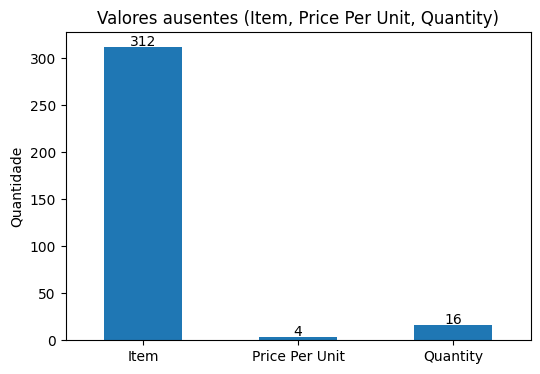

In [ ]:
df_invalid = df[df["Item"].isna()]
print(df_invalid)
print("\nQuantidade de registros que não conseguimos inferir qual é o item: ",len(df_invalid))
print(df_invalid['Price Per Unit'].unique())

df_invalid = df[df["Quantity"].isna()]
print("\nQuantidade de registros que não conseguimos inferir qual é a quantidade: ",len(df_invalid))

df_invalid = df[df["Price Per Unit"].isna()]
print("\nQuantidade de registros que não conseguimos inferir qual é o Price Per Unit: ",len(df_invalid),"\n")

cols = ["Item", "Price Per Unit", "Quantity"]

contagem_invalidos = df[cols].isna().sum()

ax = contagem_invalidos.plot(kind='bar', figsize=(6,4))
plt.title("Valores ausentes (Item, Price Per Unit, Quantity)")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

for i, v in enumerate(contagem_invalidos):
    ax.text(i, v + 1, str(v), ha='center')

plt.show()

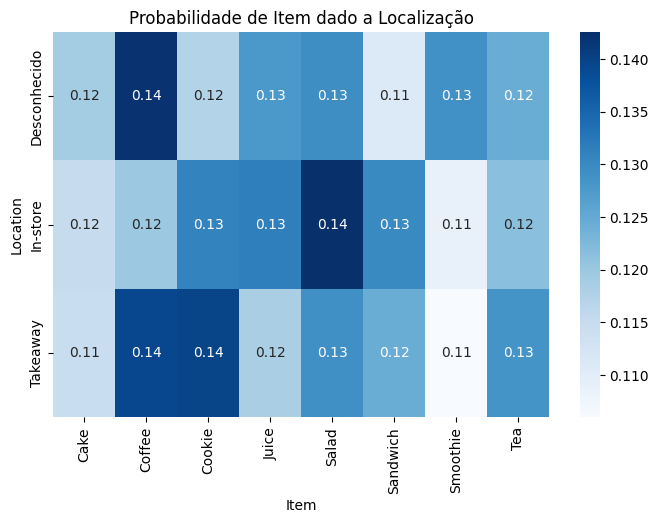

Item          Cake  Coffee  Cookie  Juice  Salad  Sandwich  Smoothie   Tea
Location                                                                  
Desconhecido  0.12    0.14    0.12   0.13   0.13      0.11      0.13  0.12
In-store      0.12    0.12    0.13   0.13   0.14      0.13      0.11  0.12
Takeaway      0.11    0.14    0.14   0.12   0.13      0.12      0.11  0.13


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

prob = pd.crosstab(df["Location"], df["Item"], normalize="index")

plt.figure(figsize=(8,5))
sns.heatmap(prob, annot=True, cmap="Blues")
plt.title("Probabilidade de Item dado a Localização")
plt.show()

print(prob.round(2))

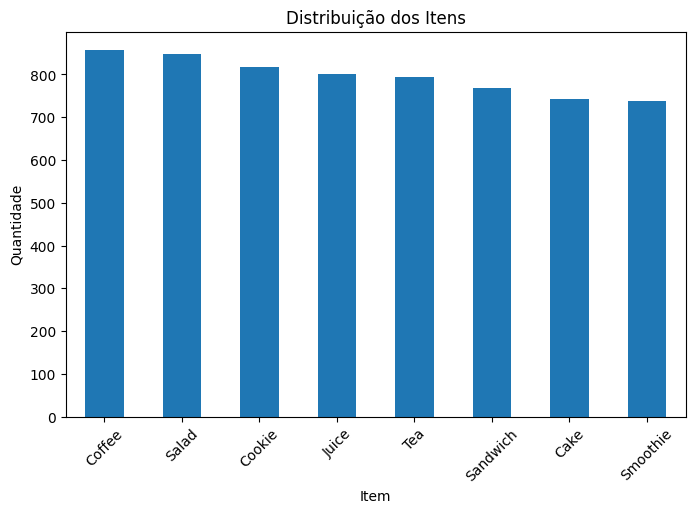

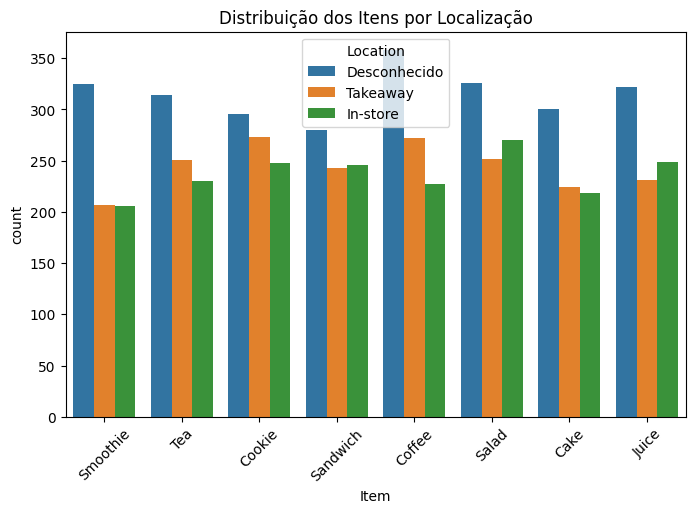

In [ ]:
import matplotlib.pyplot as plt


# Analisando a distribuição de itens na base de dados
df["Item"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Distribuição dos Itens")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()

print("\n")

# Vendo se existe correlação entre item e localização
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Item", hue="Location")
plt.title("Distribuição dos Itens por Localização")
plt.xticks(rotation=45)
plt.show()

In [ ]:
display(df.head(65))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Week Day
0,TXN_3436344,Smoothie,2.0,4.0,8.0,Desconhecido,Desconhecido,28/02/2023,2
1,TXN_4630854,Tea,1.0,1.5,1.5,Digital Wallet,Desconhecido,10/02/2023,5
2,TXN_4605871,Cookie,1.0,1.0,1.0,Desconhecido,Desconhecido,20/06/2023,2
3,TXN_2058243,Smoothie,5.0,4.0,20.0,Desconhecido,Takeaway,19/03/2023,7
4,TXN_2050017,Sandwich,4.0,4.0,16.0,Desconhecido,Takeaway,24/03/2023,5
...,...,...,...,...,...,...,...,...,...
63,TXN_5598744,Sandwich,4.0,4.0,NaN,Digital Wallet,Takeaway,17/10/2023,2
64,TXN_9513509,Sandwich,1.0,4.0,4.0,Credit Card,Desconhecido,27/04/2023,4
65,TXN_7580441,Coffee,1.0,2.0,2.0,Cash,Desconhecido,09/08/2023,3
66,TXN_5024094,Tea,1.0,1.5,1.5,Credit Card,Desconhecido,20/02/2023,1


In [ ]:
df = df.dropna(subset=["Item"]) # Removendo itens nulos
df = df.dropna(subset=["Quantity"]) # Removendo linhas com quantidade nula
print("Quantidade de linhas após as remoções: ", len(df) )

Quantidade de linhas após as remoções:  6354


### Total Spent

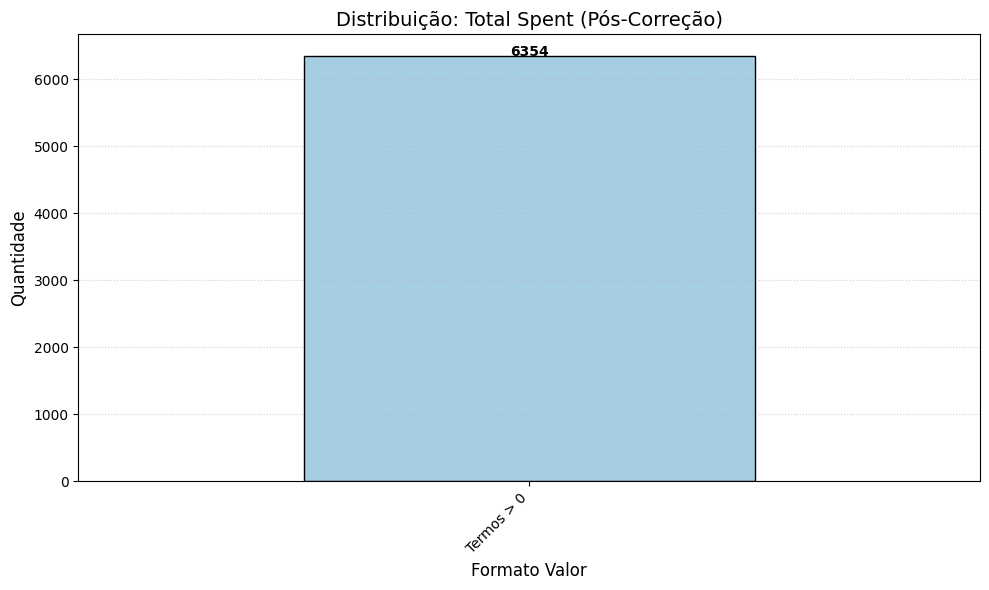

In [ ]:
def corrigir_total(linha):
    atual = linha['Total Spent']
    try:
        float(atual)
        if not pd.isna(atual):
            return atual
    except:
        pass
    try:
        q = float(linha['Quantity'])
        p = float(linha['Price Per Unit'])
        return q * p
    except:
        return atual

df['Total Spent'] = df.apply(corrigir_total, axis=1)

def categorizar_bruto(valor):
    if pd.isna(valor):
        return 'NaN'
    try:
        num = float(valor)
        return 'Termos > 0' if num > 0 else 'Termos <= 0'
    except (ValueError, TypeError):
        return str(valor)

df['Categoria_Temp'] = df['Total Spent'].apply(categorizar_bruto)
contagem = df['Categoria_Temp'].value_counts()

plt.figure(figsize=(10, 6))
cores = plt.cm.Paired(range(len(contagem)))
contagem.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Distribuição: Total Spent (Pós-Correção)', fontsize=14)
plt.xlabel('Formato Valor', fontsize=12)
plt.ylabel('Quantidade', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
for i, v in enumerate(contagem):
    plt.text(i, v, str(v), ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

df.drop(columns=['Categoria_Temp'], inplace=True)

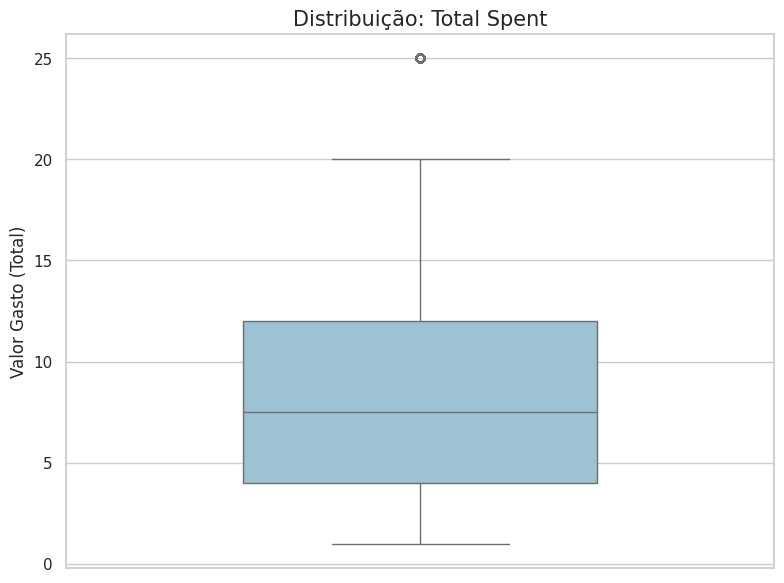

In [ ]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.boxplot(y=df['Total Spent'].dropna(), color='#92c5de', width=0.5)

plt.title('Distribuição: Total Spent', fontsize=15)
plt.ylabel('Valor Gasto (Total)')

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Total Spent'] < limite_inferior) | (df['Total Spent'] > limite_superior)]

print(f"Quantidade de outliers encontrados: {len(outliers)}")

df = df[(df['Total Spent'] >= limite_inferior) & (df['Total Spent'] <= limite_superior)]

df = df.dropna(subset=['Total Spent'])

Quantidade de outliers encontrados: 178


## Normalização

In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%d/%m/%Y', errors='coerce')

df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day

df[['Month', 'Day']] = df[['Month', 'Day']].fillna(0).astype(int)

anos_unicos = df['Year'].dropna().unique()
if len(anos_unicos) <= 1:
    print(f"Todas as transações são d3 {anos_unicos[0]}")
    df.drop(columns=['Year'], inplace=True)

df.drop(columns=['Transaction Date'], inplace=True)

Todas as transações são d3 2023


In [ ]:
scaler = MinMaxScaler()
cols_numericas = ['Total Spent']
df[cols_numericas] = scaler.fit_transform(df[cols_numericas])

In [ ]:
colunas_categoricas = ['Location', 'Payment Method']

df = pd.get_dummies(df, columns=colunas_categoricas, prefix=['Loc', 'Pay'], dtype=int)

print("Novas colunas:")
print(df.columns.tolist())

Novas colunas:
['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Week Day', 'Month', 'Day', 'Loc_Desconhecido', 'Loc_In-store', 'Loc_Takeaway', 'Pay_Cash', 'Pay_Credit Card', 'Pay_Desconhecido', 'Pay_Digital Wallet']


In [ ]:
display(df.head(10))

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Week Day,Month,Day,Loc_Desconhecido,Loc_In-store,Loc_Takeaway,Pay_Cash,Pay_Credit Card,Pay_Desconhecido,Pay_Digital Wallet
0,TXN_3436344,Smoothie,2.0,4.0,0.368421,2,2,28,1,0,0,0,0,1,0
1,TXN_4630854,Tea,1.0,1.5,0.026316,5,2,10,1,0,0,0,0,0,1
2,TXN_4605871,Cookie,1.0,1.0,0.000000,2,6,20,1,0,0,0,0,1,0
3,TXN_2058243,Smoothie,5.0,4.0,1.000000,7,3,19,0,0,1,0,0,1,0
4,TXN_2050017,Sandwich,4.0,4.0,0.789474,5,3,24,0,0,1,0,0,1,0
5,TXN_5721215,Tea,2.0,1.5,0.105263,3,5,17,0,0,1,0,0,1,0
6,TXN_5927620,Smoothie,1.0,4.0,0.157895,4,5,4,1,0,0,0,1,0,0
7,TXN_3613385,Cookie,3.0,1.0,0.105263,5,5,26,0,0,1,0,0,1,0
8,TXN_1783857,Coffee,2.0,2.0,0.157895,3,11,29,0,1,0,0,0,0,1
9,TXN_5602640,Smoothie,5.0,4.0,1.000000,6,4,1,0,0,1,0,0,1,0


## Relações

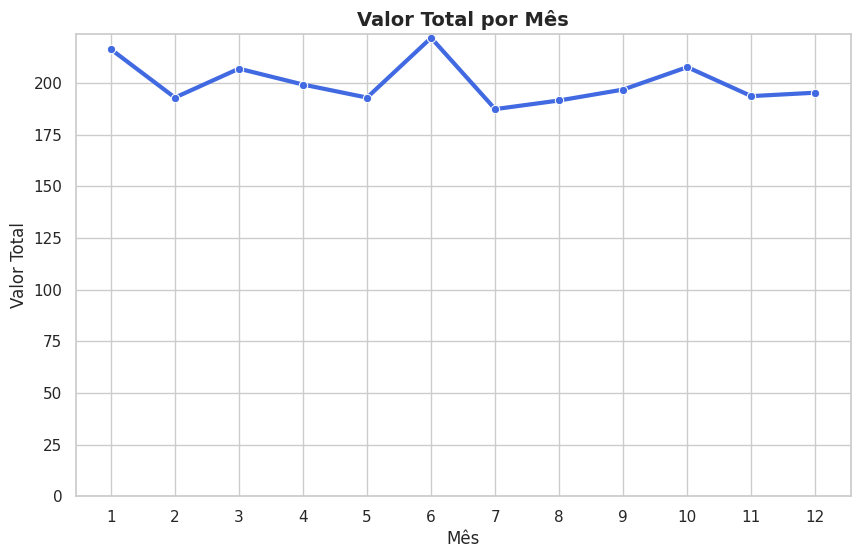

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(data=df, x='Month', y='Total Spent',
             estimator='sum',
             errorbar=None,
             marker='o',
             linewidth=3,
             color='royalblue')

plt.title('Valor Total por Mês', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Valor Total', fontsize=12)
plt.xticks(range(1, 13))
plt.ylim(0)
plt.show()

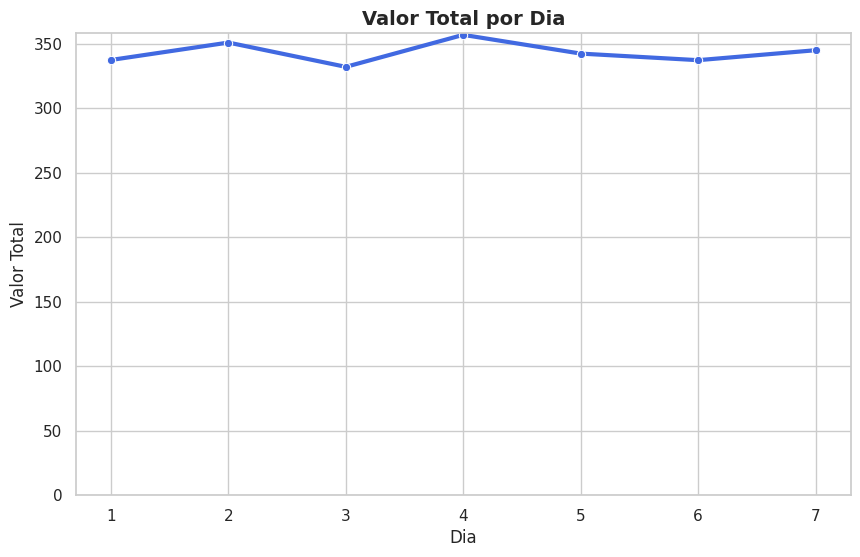

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(data=df, x='Week Day', y='Total Spent',
             estimator='sum',
             errorbar=None,
             marker='o',
             color='royalblue',
             linewidth=3)

plt.title('Valor Total por Dia', fontsize=14, fontweight='bold')
plt.xlabel('Dia', fontsize=12)
plt.ylabel('Valor Total', fontsize=12)
plt.xticks(range(1, 8))
plt.ylim(0)
plt.show()

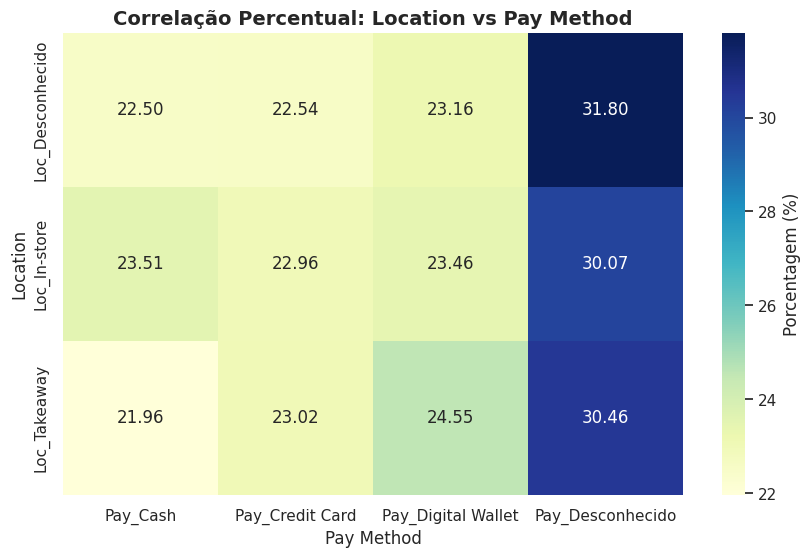

In [ ]:
loc_cols = ['Loc_Desconhecido', 'Loc_In-store', 'Loc_Takeaway']
pay_cols = ['Pay_Cash', 'Pay_Credit Card', 'Pay_Digital Wallet', 'Pay_Desconhecido']
contagem = df[loc_cols].T.dot(df[pay_cols])

tabela_percentual = contagem.div(contagem.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(tabela_percentual, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Porcentagem (%)'})

plt.title('Correlação Percentual: Location vs Pay Method', fontsize=14, fontweight='bold')
plt.xlabel('Pay Method', fontsize=12)
plt.ylabel('Location', fontsize=12)

plt.show()

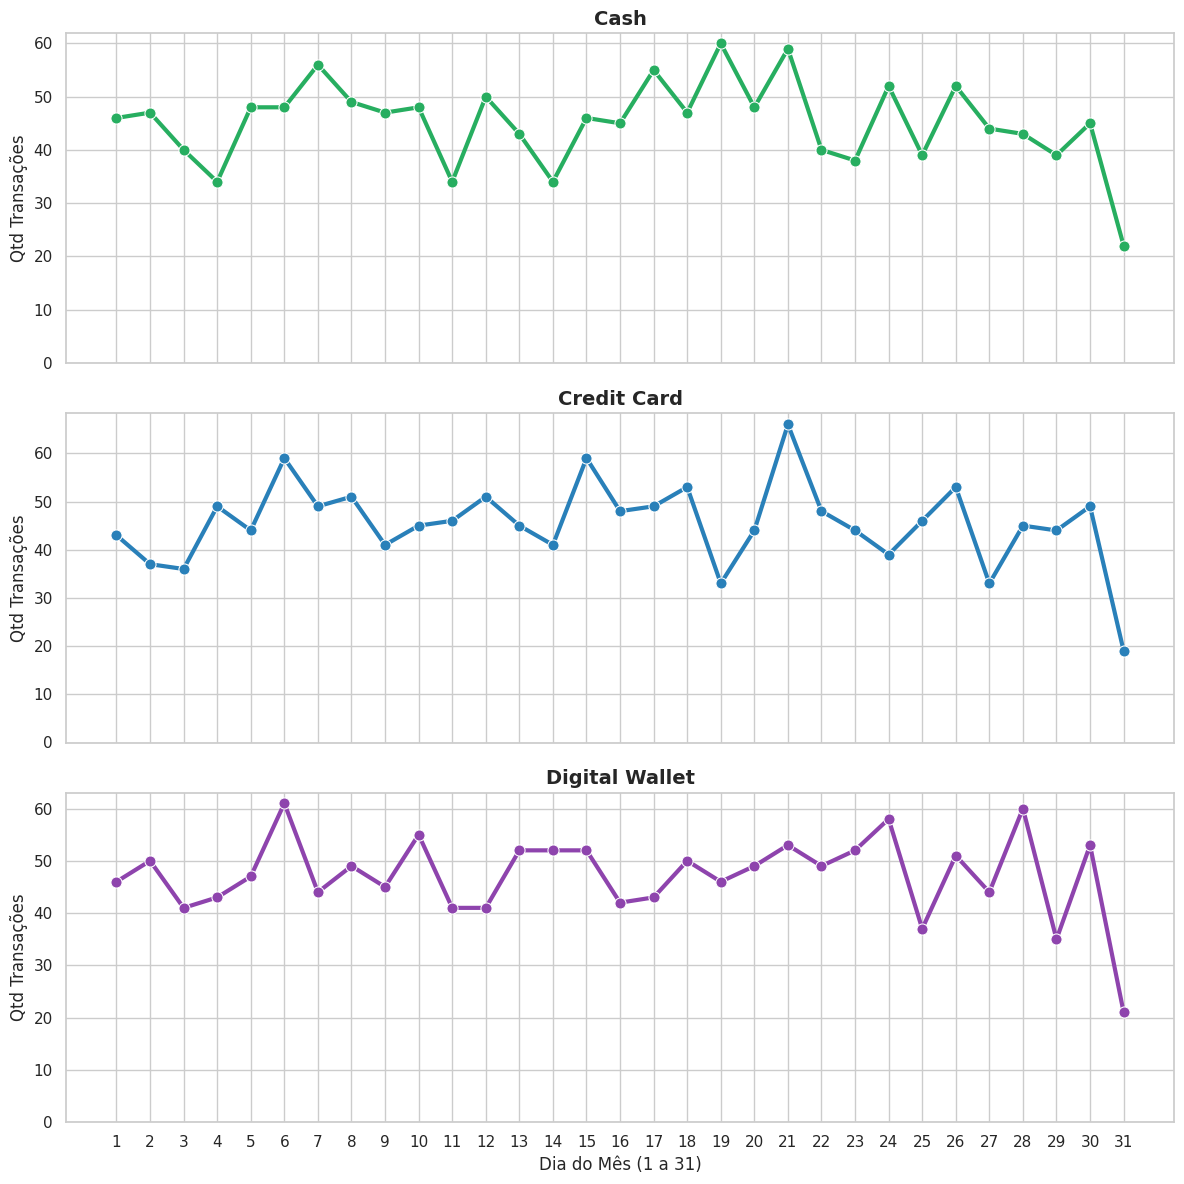

In [ ]:
df_valid = df[df['Day'] > 0].copy()

pay_cols = ['Pay_Cash', 'Pay_Credit Card', 'Pay_Digital Wallet']
titulos = ['Cash', 'Credit Card', 'Digital Wallet']
cores = ['#27ae60', '#2980b9', '#8e44ad']

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
sns.set_theme(style="whitegrid")

for i, col in enumerate(pay_cols):
    df_dia = df_valid.groupby('Day')[col].sum().reset_index()

    sns.lineplot(data=df_dia, x='Day', y=col, ax=axes[i],
                 marker='o', markersize=8, linewidth=3, color=cores[i])

    axes[i].set_title(titulos[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Qtd Transações')
    axes[i].set_ylim(0)

    axes[i].set_xticks(range(1, 32))

axes[2].set_xlabel('Dia do Mês (1 a 31)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
correlacao = df_valid[['Day'] + pay_cols].corr()['Day'][pay_cols]
print(correlacao)

Pay_Cash              0.001878
Pay_Credit Card       0.001253
Pay_Digital Wallet    0.005955
Name: Day, dtype: float64


/tmp/ipykernel_3171/1673730351.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Payment_Method', y='Total Spent', palette='Set2')


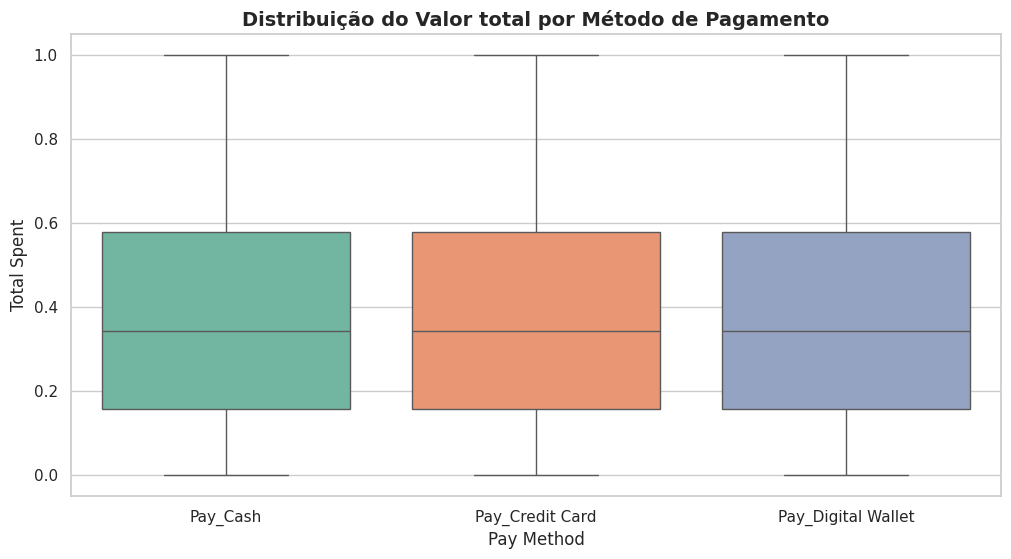

In [ ]:
pay_cols = ['Pay_Cash', 'Pay_Credit Card', 'Pay_Digital Wallet']
df_melted = df.melt(id_vars=['Total Spent'], value_vars=pay_cols,
                    var_name='Payment_Method', value_name='Used')

# Filtrar apenas onde o pagamento foi efetivamente usado (valor 1)
df_plot = df_melted[df_melted['Used'] == 1]

# 2. Plotar o Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x='Payment_Method', y='Total Spent', palette='Set2')

plt.title('Distribuição do Valor total por Método de Pagamento', fontsize=14, fontweight='bold')
plt.xlabel('Pay Method')
plt.ylabel('Total Spent')
plt.show()

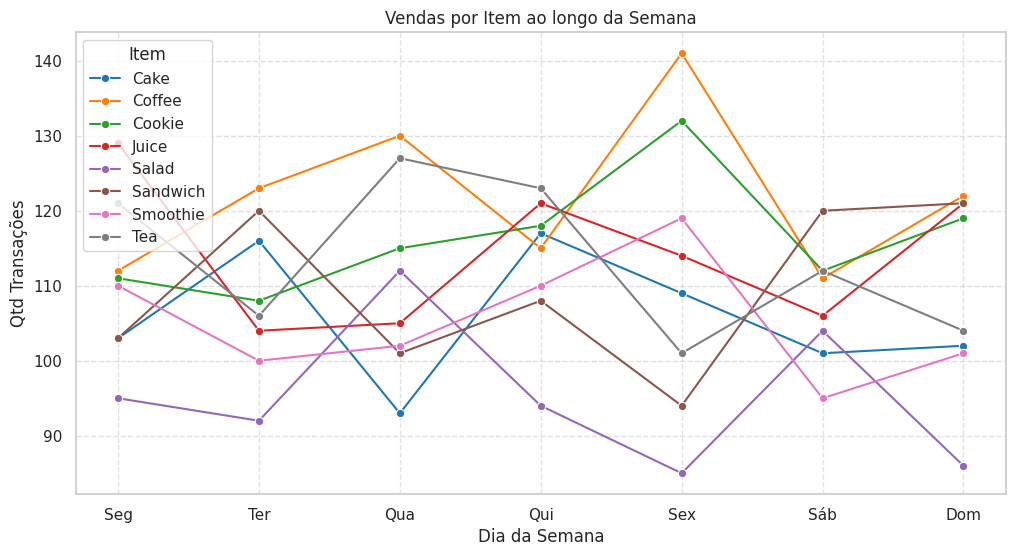

In [ ]:
df_valid = df.dropna(subset=['Week Day', 'Item']).copy()

df_group = df_valid.groupby(['Week Day', 'Item']).size().reset_index(name='Qtd')

plt.figure(figsize=(12, 6))

sns.lineplot( data=df_group, x='Week Day',y='Qtd',hue='Item',marker='o',palette='tab10' )

plt.title('Vendas por Item ao longo da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Qtd Transações')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks([1,2,3,4,5,6,7], ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom'])


plt.show()


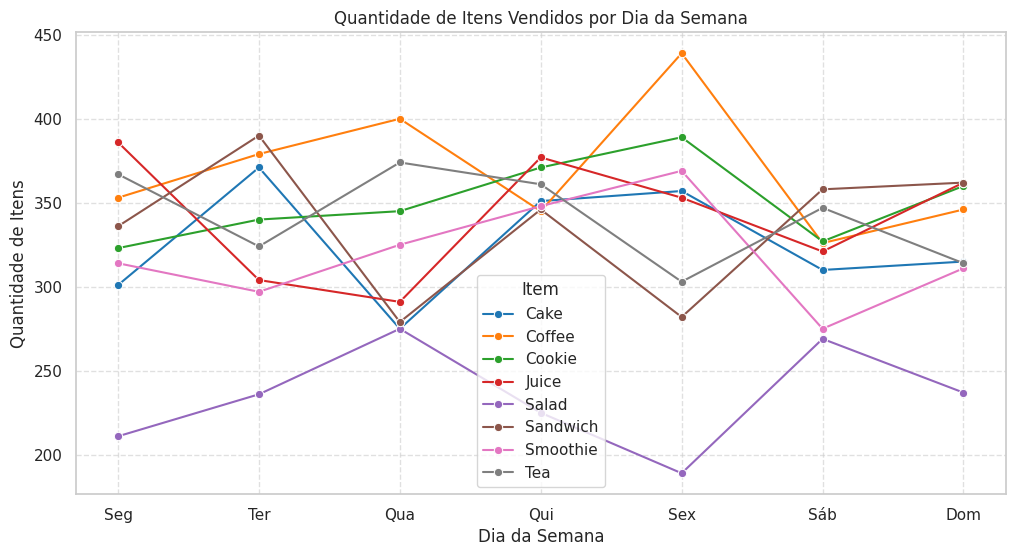

In [ ]:
df_valid = df.dropna(subset=['Week Day', 'Item', 'Quantity']).copy()

df_group = df_valid.groupby(['Week Day', 'Item'])['Quantity'].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_group,
    x='Week Day',
    y='Quantity',
    hue='Item',
    marker='o',
    palette='tab10'
)

plt.title('Quantidade de Itens Vendidos por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Quantidade de Itens')
plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks([1,2,3,4,5,6,7], ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom'])

plt.show()

In [ ]:
# Entendendo o que tem em cada coluna
for col in df.columns:
    print(df[col].astype(str).str.upper().value_counts(), "\n")

Transaction ID
TXN_7315198    1
TXN_6571898    1
TXN_8628615    1
TXN_8197935    1
TXN_9731164    1
              ..
TXN_2050017    1
TXN_2058243    1
TXN_4605871    1
TXN_4630854    1
TXN_3436344    1
Name: count, Length: 6176, dtype: int64 

Item
COFFEE      854
COOKIE      815
JUICE       800
TEA         794
SANDWICH    767
CAKE        741
SMOOTHIE    737
SALAD       668
Name: count, dtype: int64 

Quantity
2.0    1289
3.0    1245
1.0    1242
4.0    1214
5.0    1186
Name: count, dtype: int64 

Price Per Unit
3.0    1541
4.0    1504
2.0     854
1.0     815
1.5     794
5.0     668
Name: count, dtype: int64 

Total Spent
0.2631578947368421     640
0.15789473684210525    632
0.10526315789473684    615
0.5789473684210527     607
1.0                    500
0.736842105263158      475
0.3684210526315789     430
0.47368421052631576    363
0.21052631578947367    346
0.05263157894736842    338
0.42105263157894735    307
0.7894736842105263     287
0.34210526315789475    170
0.0                 

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# separando itens em colunas
df = pd.get_dummies(df, columns=["Item"], dtype=int)

# normalizando quantidade e preço unitário
scaler = MinMaxScaler()

df[["Quantity", "Price Per Unit"]] = scaler.fit_transform(
    df[["Quantity", "Price Per Unit"]]
)

In [ ]:
print(f"Total de linhas: {df.shape[0]} | Total de colunas: {df.shape[1]}")

Total de linhas: 6176 | Total de colunas: 22


In [ ]:
pd.set_option('display.max_columns', None)
print(df)

     Transaction ID  Quantity  Price Per Unit  Total Spent  Week Day  Month  \
0       TXN_3436344      0.25           0.750     0.368421         2      2   
1       TXN_4630854      0.00           0.125     0.026316         5      2   
2       TXN_4605871      0.00           0.000     0.000000         2      6   
3       TXN_2058243      1.00           0.750     1.000000         7      3   
4       TXN_2050017      0.75           0.750     0.789474         5      3   
...             ...       ...             ...          ...       ...    ...   
6995    TXN_3770267      0.25           0.500     0.263158         6     10   
6996    TXN_7367474      1.00           0.500     0.736842         7      1   
6997    TXN_2222893      0.75           0.250     0.368421         3     12   
6998    TXN_2161372      0.00           0.500     0.105263         7     12   
6999    TXN_9882625      0.00           0.750     0.157895         7      3   

      Day  Loc_Desconhecido  Loc_In-store  Loc_Take

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6176 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction ID      6176 non-null   object 
 1   Quantity            6176 non-null   float64
 2   Price Per Unit      6176 non-null   float64
 3   Total Spent         6176 non-null   float64
 4   Week Day            6176 non-null   int64  
 5   Month               6176 non-null   int64  
 6   Day                 6176 non-null   int64  
 7   Loc_Desconhecido    6176 non-null   int64  
 8   Loc_In-store        6176 non-null   int64  
 9   Loc_Takeaway        6176 non-null   int64  
 10  Pay_Cash            6176 non-null   int64  
 11  Pay_Credit Card     6176 non-null   int64  
 12  Pay_Desconhecido    6176 non-null   int64  
 13  Pay_Digital Wallet  6176 non-null   int64  
 14  Item_Cake           6176 non-null   int64  
 15  Item_Coffee         6176 non-null   int64  
 16  Item_Cookie